In [1]:
# CELL 1
!pip install mediapipe==0.10.20 --no-deps -q
import warnings
warnings.filterwarnings('ignore')

import sys
import json
import gc
from pathlib import Path
from collections import Counter

import numpy as np
import cv2

# Try importing TensorFlow
try:
    import tensorflow as tf
    print(f"TensorFlow: {tf.__version__}")
except ImportError:
    print("✗ TensorFlow not available")
    tf = None

# Import MediaPipe
import mediapipe as mp
print(f"MediaPipe: {mp.__version__}")

# Other imports
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("\nAll imports completed!")
print(f"Has solutions: {hasattr(mp, 'solutions')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 57.3 MB/s eta 0:00:00


2026-02-24 17:53:58.598005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771955638.776262      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771955638.830793      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771955639.244697      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771955639.244735      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771955639.244737      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
MediaPipe: 0.10.20

All imports completed!
Has solutions: True


In [2]:
# CELL 2
import os
import sys
import json
import gc
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import cv2
import tensorflow as tf
import mediapipe as mp
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("All imports successful!")
print(f"Python: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"MediaPipe: {mp.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")

CONFIG = {
    'img_size': 128,
    'batch_size': 64,
    'epochs': 35,
    'learning_rate': 0.001,
    'raw_dataset_path': '/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train',  # UPDATE THIS PATH
    'model_save_path': '/kaggle/working/asl_model.keras',
}

class KaggleSkeletonGenerator:
    def __init__(self, target_size=(128, 128)):
        self.target_size = target_size
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=True,
            max_num_hands=1,
            min_detection_confidence=0.5
        )
        self.mp_draw = mp.solutions.drawing_utils
        
    def extract_skeleton(self, image):
        if image is None or image.size == 0:
            return None, False
            
        # Convert to RGB
        if len(image.shape) == 2:
            rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif image.shape[2] == 3:
            rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            rgb = image
            
        rgb = cv2.resize(rgb, self.target_size)
        
        # Process
        results = self.hands.process(rgb)
        canvas = np.zeros(self.target_size + (3,), dtype=np.uint8)
        
        if results.multi_hand_landmarks:
            self.mp_draw.draw_landmarks(
                canvas,
                results.multi_hand_landmarks[0],
                self.mp_hands.HAND_CONNECTIONS,
                landmark_drawing_spec=self.mp_draw.DrawingSpec(
                    color=(255, 255, 255), thickness=2, circle_radius=2
                ),
                connection_drawing_spec=self.mp_draw.DrawingSpec(
                    color=(255, 255, 255), thickness=2
                )
            )
            return canvas, True
        
        # Fallback
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR), False

print("Setup complete!")

All imports successful!
Python: 3.12.12
TensorFlow: 2.19.0
MediaPipe: 0.10.20
OpenCV: 4.12.0
NumPy: 2.0.2
Setup complete!


In [3]:
# CELL 3 - Load & Preprocess Dataset
def load_and_preprocess(dataset_path, img_size=128, max_per_class=None):
    generator = KaggleSkeletonGenerator(target_size=(img_size, img_size))
    
    data, labels = [], []
    class_names = []
    stats = {'processed': 0, 'fallback': 0, 'failed': 0}
    
    dataset_path = Path(dataset_path)
    class_folders = sorted([d for d in dataset_path.iterdir() if d.is_dir()])
    
    print(f"Found {len(class_folders)} classes")
    
    for class_idx, folder in enumerate(class_folders):
        class_names.append(folder.name)
        images = list(folder.glob('*.jpg')) + list(folder.glob('*.png')) + list(folder.glob('*.jpeg'))
        
        if max_per_class:
            images = images[:max_per_class]
            
        print(f"\n[{class_idx+1}/{len(class_folders)}] {folder.name}: {len(images)} images")
        
        for img_path in tqdm(images, desc=folder.name):
            try:
                img = cv2.imread(str(img_path))
                if img is None:
                    stats['failed'] += 1
                    continue
                
                skeleton, detected = generator.extract_skeleton(img)
                skeleton = skeleton.astype(np.float32) / 255.0
                
                data.append(skeleton)
                labels.append(class_idx)
                stats['processed'] += 1
                
                if not detected:
                    stats['fallback'] += 1
                    
            except Exception as e:
                stats['failed'] += 1
        
        gc.collect()
    
    print(f"\nDone! Processed: {stats['processed']}, Fallback: {stats['fallback']}, Failed: {stats['failed']}")
    return np.array(data), np.array(labels), class_names, stats

# EXECUTE
X, y, class_names, stats = load_and_preprocess(
    CONFIG['raw_dataset_path'], 
    CONFIG['img_size'],
    max_per_class=1500  # you can change this if you want
)

print(f"\nDataset: {X.shape}, Labels: {y.shape}")
print(f"Classes: {class_names}")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1771955662.181797      64 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771955662.210786      64 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Found 29 classes

[1/29] A: 1500 images


A: 100%|██████████| 1500/1500 [00:43<00:00, 34.31it/s]



[2/29] B: 1500 images


B: 100%|██████████| 1500/1500 [00:47<00:00, 31.61it/s]


...


[28/29] nothing: 1500 images


nothing: 100%|██████████| 1500/1500 [00:38<00:00, 38.94it/s]



[29/29] space: 1500 images


space: 100%|██████████| 1500/1500 [00:50<00:00, 29.47it/s]



Done! Processed: 43500, Fallback: 10365, Failed: 0

Dataset: (43500, 128, 128, 3), Labels: (43500,)
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [4]:
# CELL 4 - Split Data
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

del X, y, X_temp
gc.collect()

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 27840, Val: 6960, Test: 8700


In [5]:
# CELL 5 - Data Augmentation & Weights
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=False, fill_mode='nearest'
)

train_gen = train_datagen.flow(X_train, y_train, batch_size=CONFIG['batch_size'])
val_gen = tf.keras.preprocessing.image.ImageDataGenerator().flow(X_val, y_val, batch_size=CONFIG['batch_size'])

class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))
print("Class weights computed")

Class weights computed


In [6]:
# CELL 6 - Build Model
def create_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=input_shape),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.25),
        
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.25),
        
        tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.25),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = create_model((128, 128, 3), len(class_names))
model.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1771957178.624254      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,715,837 (33.25 MB)

 Trainable params: 8,714,173 (33.24 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [7]:
# CELL 7 - Train
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(CONFIG['model_save_path'], monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // CONFIG['batch_size'],
    epochs=CONFIG['epochs'],
    validation_data=val_gen,
    validation_steps=len(X_val) // CONFIG['batch_size'],
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/35


I0000 00:00:1771957186.872117      78 service.cc:152] XLA service 0x7b763400af90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771957186.872160      78 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771957187.895840      78 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/435 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.0195 - loss: 4.8285   

I0000 00:00:1771957198.692192      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


435/435 ━━━━━━━━━━━━━━━━━━━━ 113s 221ms/step - accuracy: 0.0896 - loss: 3.8042 - val_accuracy: 0.1780 - val_loss: 2.8690 - learning_rate: 0.0010
Epoch 2/35
435/435 ━━━━━━━━━━━━━━━━━━━━ 94s 217ms/step - accuracy: 0.3047 - loss: 2.2960 - val_accuracy: 0.6266 - val_loss: 1.3040 - learning_rate: 0.0010
Epoch 3/35
435/435 ━━━━━━━━━━━━━━━━━━━━ 92s 212ms/step - accuracy: 0.5517 - loss: 1.3846 - val_accuracy: 0.7701 - val_loss: 0.7502 - learning_rate: 0.0010
Epoch 4/35
435/435 ━━━━━━━━━━━━━━━━━━━━ 93s 214ms/step - accuracy: 0.6901 - loss: 0.9582 - val_accuracy: 0.5326 - val_loss: 2.1356 - learning_rate: 0.0010
Epoch 5/35
435/435 ━━━━━━━━━━━━━━━━━━━━ 92s 212ms/step - accuracy: 0.7647 - loss: 0.7240 - val_accuracy: 0.6905 - val_loss: 1.4432 - learning_rate: 0.0010
Epoch 6/35
435/435 ━━━━━━━━━━━━━━━━━━━━ 93s 213ms/step - accuracy: 0.7963 - loss: 0.6324 - val_accuracy: 0.7891 - val_loss: 0.8175 - learning_rate: 0.0010
Epoch 7/35
435/435 ━━━━━━━━━━━━━━━━━━━━ 93s 213ms/step - accuracy: 0.8455 - loss

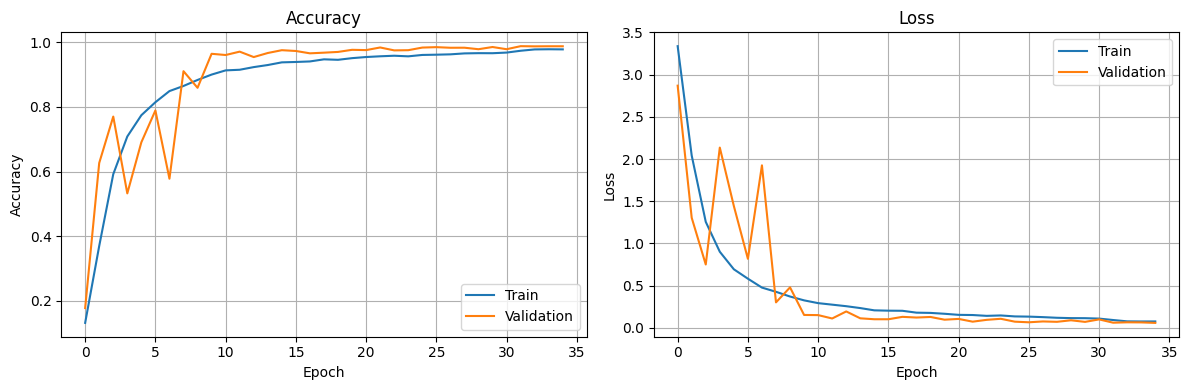

Final Train Acc: 0.9779
Final Val Acc: 0.9876
Best Val Acc: 0.9878


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Train Acc: {history.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best Val Acc: {max(history.history['val_accuracy']):.4f}")

In [9]:
# Calculate gap
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
gap = train_acc - val_acc

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy: {val_acc:.4f}")
print(f"Gap: {gap:.4f}")

if gap > 0.05:
    print("Possible overfitting (gap > 5%)")
elif gap > 0.02:
    print("Slight overfitting (gap 2-5%)")
else:
    print("Good fit (gap < 2%)")

Train Accuracy: 0.9779
Val Accuracy: 0.9876
Gap: -0.0096
Good fit (gap < 2%)


In [10]:
# CELL 8 - Evaluate & Save
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

with open('/kaggle/working/class_mapping.json', 'w') as f:
    json.dump({i: name for i, name in enumerate(class_names)}, f)

print("\nFiles saved:")
print("- asl_model.h5")
print("- class_mapping.json")

272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9881 - loss: 0.0436

Test Accuracy: 0.9890

Files saved:
- asl_model.h5
- class_mapping.json
